In [121]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd

In [122]:
X, y = make_blobs(  # making a dataset
    n_samples= 1000,
    centers = 3,
    n_features = 2

)

In [123]:
X

array([[-9.01007578,  4.39494719],
       [ 7.78959121,  0.65957881],
       [-2.25947194, -6.94110076],
       ...,
       [ 8.48383655,  1.68919011],
       [-9.60591272,  3.08610804],
       [-2.17346384, -7.21282473]], shape=(1000, 2))

In [124]:
y

array([1, 2, 0, 0, 2, 0, 1, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 1, 1, 2, 0,
       0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0, 0, 1,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 2, 0,
       0, 1, 2, 0, 0, 1, 2, 0, 0, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1, 1, 1, 1,
       2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 0, 0, 2, 1, 2, 0, 1, 1, 0, 0, 1,
       0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 2,
       2, 0, 1, 2, 2, 2, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 2, 2, 1, 1, 0, 2,
       0, 1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 0, 0, 0, 2, 0, 0, 1, 1, 0, 2, 2,
       2, 0, 0, 0, 2, 1, 0, 0, 2, 0, 1, 2, 2, 2, 1, 0, 0, 1, 0, 0, 2, 2,
       1, 0, 0, 1, 2, 1, 2, 0, 1, 1, 1, 1, 2, 0, 2, 1, 1, 2, 2, 1, 1, 0,
       1, 1, 2, 0, 1, 2, 0, 2, 1, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 2,
       2, 1, 2, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1,
       1, 2, 0, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 2, 2, 1, 0,
       2, 0, 2, 0, 2, 1, 2, 0, 2, 2, 1, 2, 1, 0, 2,

``` 
AS I am applying Un-supervised learning ... means we don't need the Output and cluter input features 
so we will not Use *y*

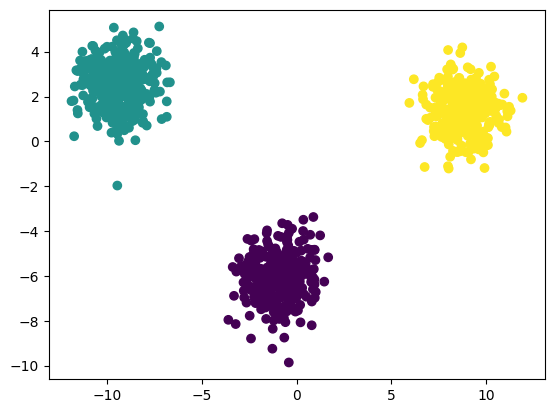

In [125]:
plt.scatter(X[:,0], X[:,1], c = y)

___
# train test split 
___

In [126]:
from sklearn.model_selection import train_test_split

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size = 0.25 , random_state = 43)

___
# Standardization 
___

In [128]:
from sklearn.preprocessing import StandardScaler

In [129]:
scaler = StandardScaler()

In [130]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

___
# Model Training 
___

In [131]:
from sklearn.cluster import KMeans

``` 
Elbow method to Select K value

In [132]:
wcss = []
for k in range(1,11):
    model = KMeans(n_clusters = k, init = "k-means++")
    model.fit(X_train_scaled)
    wcss.append(model.inertia_) # wcss is stored in interia_ method

In [133]:
## all the wcss values 
wcss

[1499.9999999999984,
 815.1169286333654,
 60.50231259404731,
 52.02818439754433,
 39.717678510528856,
 31.262319062600238,
 28.530137031537123,
 25.75232692332481,
 23.64478490401484,
 21.491939478056608]

Text(0.5, 0, 'WCSS')

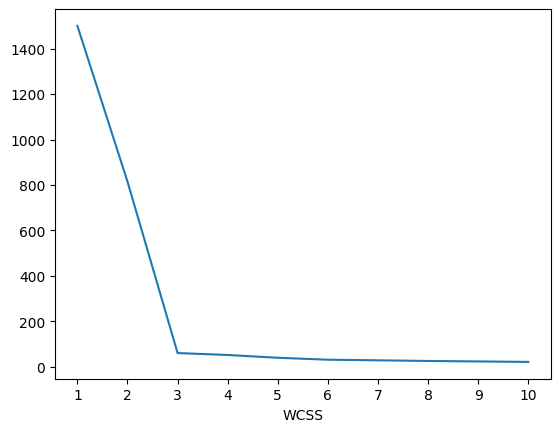

In [134]:
# Plot Elbow Curve 
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("number of cluter ")
plt.xlabel("WCSS")

```
Find region where Value knucle down and then becomes Stable 
see 3 is that point

In [135]:
kmeans = KMeans(n_clusters =3, init="k-means++")

kmeans.fit_predict(X_train_scaled)

array([0, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 0, 2, 0, 0, 2, 2, 1, 1, 2, 1,
       0, 2, 1, 1, 0, 1, 1, 2, 2, 2, 2, 1, 0, 2, 1, 0, 0, 1, 0, 2, 0, 2,
       1, 0, 0, 1, 0, 2, 0, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 0, 2,
       1, 1, 0, 1, 2, 2, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2, 0, 1, 1, 0, 2, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 0, 2, 2, 1, 0, 1, 2,
       2, 1, 0, 2, 1, 2, 1, 1, 1, 0, 2, 2, 1, 1, 1, 2, 0, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 2, 1, 1, 2, 0, 0, 1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 2, 1,
       0, 1, 2, 1, 2, 0, 0, 0, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 0, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 2, 0, 2, 1, 2, 0, 2, 1, 2, 2,
       0, 2, 1, 1, 0, 2, 1, 2, 1, 0, 2, 1, 2, 1, 0, 2, 1, 1, 2, 0, 0, 2,
       1, 0, 2, 0, 2, 2, 1, 0, 2, 0, 2, 0, 0, 1, 2, 1, 1, 2, 2, 1, 0, 2,
       0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 0, 0, 2, 1, 0, 2, 0, 0, 0, 2,
       2, 1, 2, 2, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0, 2,
       0, 0, 2, 0, 1, 0, 0, 2, 1, 1, 1, 0, 0, 0, 2,

In [136]:
y_pred = kmeans.predict(X_test_scaled)

In [137]:
y_pred


array([0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 1, 1, 2, 0, 2, 2, 1, 1, 0, 2,
       2, 1, 0, 0, 0, 0, 1, 2, 2, 0, 2, 0, 2, 0, 1, 1, 2, 1, 1, 2, 1, 0,
       0, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 0, 0, 2, 0, 0, 2, 1, 2, 2, 1, 0,
       0, 2, 2, 1, 0, 2, 2, 2, 2, 0, 2, 1, 1, 1, 2, 2, 0, 0, 0, 1, 1, 1,
       0, 2, 0, 1, 0, 0, 1, 0, 0, 2, 1, 1, 2, 1, 1, 2, 1, 0, 0, 0, 2, 1,
       1, 1, 2, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 2, 2, 2, 1, 2, 0, 1, 1, 0,
       0, 1, 0, 2, 0, 2, 2, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 0, 0, 2, 2,
       1, 0, 2, 2, 2, 1, 2, 1, 0, 1, 0, 2, 1, 2, 0, 0, 2, 2, 0, 1, 0, 1,
       2, 1, 0, 2, 2, 2, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 2, 2, 1, 2, 2, 2,
       2, 2, 0, 2, 1, 2, 0, 1, 2, 2, 0, 2, 0, 1, 1, 2, 2, 0, 0, 1, 1, 2,
       2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 2, 0, 1, 1, 1, 1, 0, 1, 2, 1,
       2, 0, 1, 0, 2, 2, 2, 0], dtype=int32)

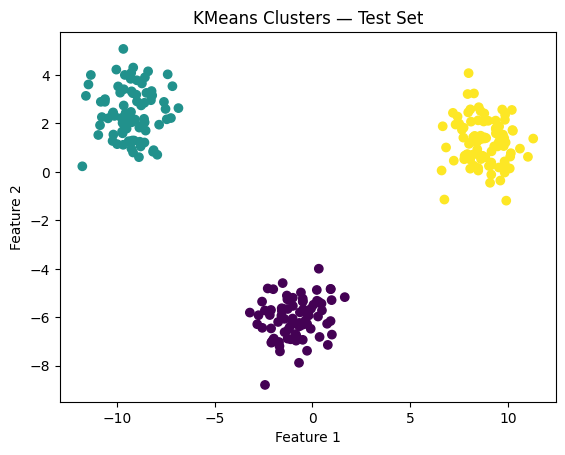

In [138]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clusters — Test Set")
plt.show()

___
# Validating the K value 

    > kneelocator
    >silhoute scoring
___


# Knee Locator

In [139]:
from kneed import KneeLocator 

In [140]:

kl = KneeLocator(
    range(1, 11),
    wcss,
    curve="convex",
    direction="decreasing"
)

In [141]:
kl.elbow

# i am also getting 3 ... so Validate K value 

np.int64(3)

# Silhoutte Scoring

In [142]:
from sklearn.metrics import silhouette_score

In [143]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k  , init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)


In [144]:
silhouette_coefficients

[0.592305650799849,
 0.8478316212748517,
 0.6873404170483062,
 0.6773871319101832,
 0.39959322296255856,
 0.37952764002744405,
 0.3500216072047792,
 0.3382206977254758,
 0.34443557298507643]

Text(0, 0.5, 'Silhoute Score')

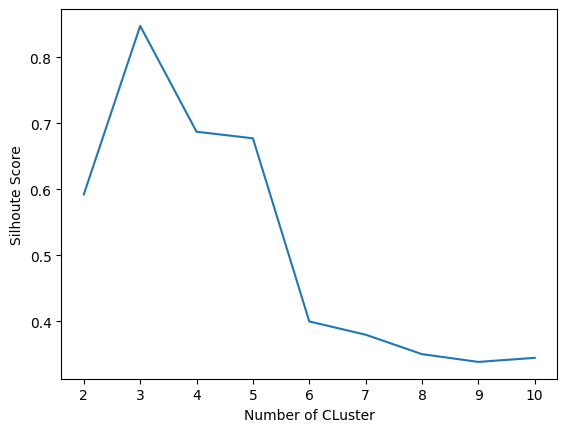

In [145]:
# ploting the score 
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of CLuster")
plt.ylabel("Silhoute Score")

```
Observe st three the score is highest 